# 5. Evaluación del Modelo - Informe de Rendimiento

**Objetivo:**  
Generar un informe completo de rendimiento del mejor modelo (XGBoost) incluyendo:
- Gráfico de valores predichos vs reales
- Histograma de residuos
- Gráfico de dispersión de residuos vs predicciones
- Importancia de características (feature importance)
- Interpretación de métricas en términos de negocio

**Modelo evaluado:** XGBoost (guardado como `best_model_XGBoost.pkl`)  
**Dataset:** Pet adoption data - Austin Animal Center  
**Conjunto de evaluación:** TEST (15% del dataset, 7,881 registros)

---

In [41]:
# ============================================
# Importaciones
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Configuración visual
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 5.1 Carga del Modelo y Datos

Cargamos:
1. El modelo entrenado (pipeline completo con preprocesador + XGBoost)
2. El dataset limpio
3. Recreamos el split train/val/test **con la misma semilla** (random_state=42)

---

In [42]:
# ============================================
# Cargar Modelo Entrenado
# ============================================

modelo_path = '../models/best_model_XGBoost.pkl'
best_model = joblib.load(modelo_path)

print("="*70)
print("MODELO CARGADO")
print("="*70)
print(f"\n✅ Archivo: {modelo_path}")
print(f"✅ Pipeline: {type(best_model)}")
print(f"\n📋 Componentes del pipeline:")
print(f"   1. Preprocesador: {type(best_model.named_steps['preprocessor'])}")
print(f"   2. Modelo:        {type(best_model.named_steps['model'])}")

MODELO CARGADO

✅ Archivo: ../models/best_model_XGBoost.pkl
✅ Pipeline: <class 'sklearn.pipeline.Pipeline'>

📋 Componentes del pipeline:
   1. Preprocesador: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
   2. Modelo:        <class 'xgboost.sklearn.XGBRegressor'>


In [43]:
# ============================================
# Cargar Dataset
# ============================================

df = pd.read_csv('../data/pet_adoption_model.csv')

print("\n" + "="*70)
print("DATASET CARGADO")
print("="*70)
print(f"\nRegistros: {len(df):,}")
print(f"Columnas:  {df.shape[1]}")


DATASET CARGADO

Registros: 52,535
Columnas:  12


In [44]:
# ============================================
# Recrear Split Train/Val/Test (70/15/15)
# IMPORTANTE: Usar random_state=42 (igual que en entrenamiento)
# ============================================

FEATURES = [
    'AnimalType',
    'Sex',
    'IntakeType',
    'IntakeCondition',
    'AgeInDays',
    'AgeGroup',
    'breed_type',
    'Breed_grouped',
    'Color_grouped'
]

TARGET = 'TimeInShelterDays_log'

X = df[FEATURES].copy()
y = df[TARGET].copy()

# Paso 1: separar test (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Paso 2: del 85% restante, sacar validation (~15% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42
)

print("\n" + "="*70)
print("SPLIT RECREADO (70/15/15)")
print("="*70)
print(f"\nTrain:      {len(X_train):,} filas ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):,} filas ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):,} filas ({len(X_test)/len(X)*100:.1f}%)")
print(f"\n✅ Usando conjunto de TEST para evaluación final")


SPLIT RECREADO (70/15/15)

Train:      36,772 filas (70.0%)
Validation: 7,882 filas (15.0%)
Test:       7,881 filas (15.0%)

✅ Usando conjunto de TEST para evaluación final


## 5.2 Generar Predicciones en TEST
Con nuestro modelo entrenado predecimos los valores del conjunto de TEST.

**Importante:** Las predicciones están en escala logarítmica (`log(días + 1)`).  
Para interpretarlas en días reales, debemos aplicar la transformación inversa: `np.expm1()`

---

In [45]:
# ============================================
# Predicciones en TEST
# ============================================

# Predicciones en escala log
y_test_pred_log = best_model.predict(X_test)

# Convertir a días reales (deshacer log)
y_test_dias = np.expm1(y_test)  # Valores reales en días
y_pred_dias = np.expm1(y_test_pred_log)  # Predicciones en días

print("="*70)
print("PREDICCIONES GENERADAS")
print("="*70)
print(f"\n✅ Predicciones en TEST: {len(y_test_pred_log):,} registros")
print(f"\n📊 Muestra de predicciones (primeros 5):")
print(f"\n   {'Real (días)':<15} {'Predicho (días)':<18} {'Error (días)'}")
print(f"   {'-'*50}")
for i in range(5):
    error = y_test_dias.iloc[i] - y_pred_dias[i]
    print(f"   {y_test_dias.iloc[i]:>13.1f}   {y_pred_dias[i]:>16.1f}   {error:>13.1f}")

PREDICCIONES GENERADAS

✅ Predicciones en TEST: 7,881 registros

📊 Muestra de predicciones (primeros 5):

   Real (días)     Predicho (días)    Error (días)
   --------------------------------------------------
            18.0               13.0             5.0
            14.0               15.4            -1.4
            48.0               12.9            35.1
             3.0               13.9           -10.9
            46.0               57.2           -11.2


## 5.3 Métricas de Evaluación

Calculamos las métricas estándar de regresión:

- **MAE (Mean Absolute Error):** Error promedio en valor absoluto
- **RMSE (Root Mean Squared Error):** Raíz del error cuadrático medio (penaliza más los errores grandes)
- **R² (Coefficient of Determination):** Porcentaje de varianza explicada por el modelo (0-1, donde 1 es perfecto)

Las calculamos en **dos escalas**:
1. Escala logarítmica (como fue entrenado el modelo)
2. Días reales (para interpretación de negocio)

---

In [46]:
# ============================================
# Cálculo de Métricas
# ============================================

# Métricas en escala LOG
mae_log = mean_absolute_error(y_test, y_test_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test, y_test_pred_log))
r2_log = r2_score(y_test, y_test_pred_log)

# Métricas en DÍAS REALES
mae_dias = mean_absolute_error(y_test_dias, y_pred_dias)
rmse_dias = np.sqrt(mean_squared_error(y_test_dias, y_pred_dias))
r2_dias = r2_score(y_test_dias, y_pred_dias)

print("="*70)
print("MÉTRICAS DE EVALUACIÓN EN TEST")
print("="*70)

print(f"\n📊 ESCALA LOGARÍTMICA (como fue entrenado):")
print(f"   {'Métrica':<25} {'Valor':>12}")
print(f"   {'-'*38}")
print(f"   {'MAE (log)':<25} {mae_log:>12.4f}")
print(f"   {'RMSE (log)':<25} {rmse_log:>12.4f}")
print(f"   {'R² (log)':<25} {r2_log:>12.4f}")

print(f"\n📊 DÍAS REALES (interpretación de negocio):")
print(f"   {'Métrica':<25} {'Valor':>12}")
print(f"   {'-'*38}")
print(f"   {'MAE (días)':<25} {mae_dias:>12.1f} días")
print(f"   {'RMSE (días)':<25} {rmse_dias:>12.1f} días")
print(f"   {'R²':<25} {r2_dias:>12.4f}")

print(f"\n📊 ESTADÍSTICAS DE LOS DATOS:")
print(f"   {'Estadístico':<25} {'Valor':>12}")
print(f"   {'-'*38}")
print(f"   {'Media real (días)':<25} {y_test_dias.mean():>12.1f} días")
print(f"   {'Mediana real (días)':<25} {y_test_dias.median():>12.1f} días")
print(f"   {'Desv. estándar (días)':<25} {y_test_dias.std():>12.1f} días")
print(f"   {'Mínimo (días)':<25} {y_test_dias.min():>12.1f} días")
print(f"   {'Máximo (días)':<25} {y_test_dias.max():>12.1f} días")

MÉTRICAS DE EVALUACIÓN EN TEST

📊 ESCALA LOGARÍTMICA (como fue entrenado):
   Métrica                          Valor
   --------------------------------------
   MAE (log)                       0.8574
   RMSE (log)                      1.0902
   R² (log)                        0.2377

📊 DÍAS REALES (interpretación de negocio):
   Métrica                          Valor
   --------------------------------------
   MAE (días)                        30.5 días
   RMSE (días)                       61.2 días
   R²                             -0.0176

📊 ESTADÍSTICAS DE LOS DATOS:
   Estadístico                      Valor
   --------------------------------------
   Media real (días)                 42.0 días
   Mediana real (días)               17.0 días
   Desv. estándar (días)             60.7 días
   Mínimo (días)                      1.0 días
   Máximo (días)                    365.0 días


## 5.4 Visualización 1: Predicciones vs Valores Reales

**Objetivo:** Evaluar visualmente qué tan bien el modelo predice los valores reales.

**Interpretación:**
- **Línea roja diagonal:** Predicción perfecta (predicho = real)
- **Puntos cercanos a la línea:** Buenas predicciones
- **Puntos alejados de la línea:** Errores grandes
- **Patrón disperso:** El modelo tiene dificultad para capturar la variabilidad

**Escala:** Mostramos ambas escalas (log y días reales) para comparar.

---

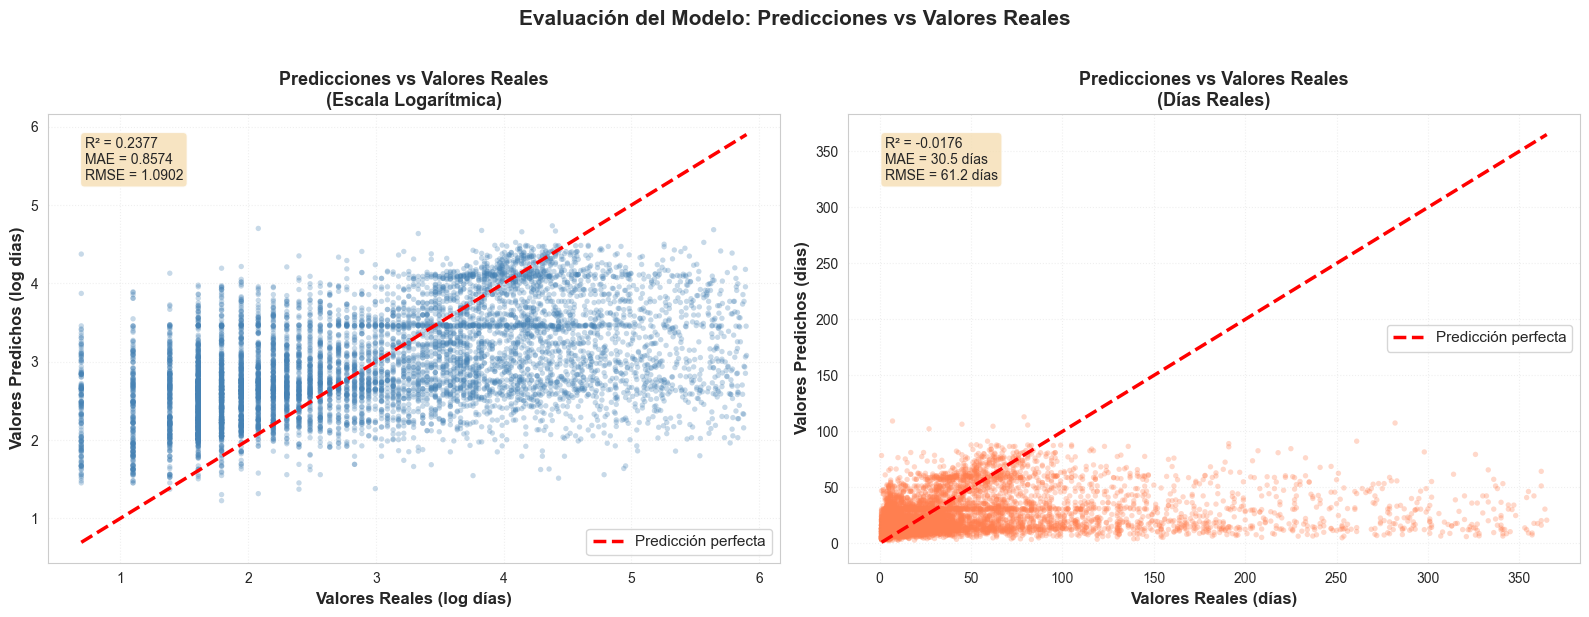


📊 INTERPRETACIÓN DEL GRÁFICO:
   ✅ Puntos cercanos a la línea roja = buenas predicciones
   ⚠️  Dispersión indica que el modelo tiene dificultad con algunos casos
   📌 R² = -0.0176 significa que el modelo explica el -1.8% de la variabilidad


In [47]:
# ============================================
# GRÁFICO 1: Predicted vs Actual
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==================== SUBPLOT 1: Escala LOG ====================
axes[0].scatter(y_test, y_test_pred_log, alpha=0.3, s=15, color='steelblue', edgecolors='none')

# Línea de predicción perfecta
lims_log = [min(y_test.min(), y_test_pred_log.min()),
            max(y_test.max(), y_test_pred_log.max())]
axes[0].plot(lims_log, lims_log, 'r--', linewidth=2.5, label='Predicción perfecta', zorder=5)

axes[0].set_xlabel('Valores Reales (log días)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Valores Predichos (log días)', fontsize=12, fontweight='bold')
axes[0].set_title('Predicciones vs Valores Reales\n(Escala Logarítmica)', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, linestyle=':')

# Añadir métricas en el gráfico
textstr = f'R² = {r2_log:.4f}\nMAE = {mae_log:.4f}\nRMSE = {rmse_log:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

# ==================== SUBPLOT 2: Días REALES ====================
axes[1].scatter(y_test_dias, y_pred_dias, alpha=0.3, s=15, color='coral', edgecolors='none')

# Línea de predicción perfecta
lims_dias = [min(y_test_dias.min(), y_pred_dias.min()),
             max(y_test_dias.max(), y_pred_dias.max())]
axes[1].plot(lims_dias, lims_dias, 'r--', linewidth=2.5, label='Predicción perfecta', zorder=5)

axes[1].set_xlabel('Valores Reales (días)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Valores Predichos (días)', fontsize=12, fontweight='bold')
axes[1].set_title('Predicciones vs Valores Reales\n(Días Reales)', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, linestyle=':')

# Añadir métricas en el gráfico
textstr = f'R² = {r2_dias:.4f}\nMAE = {mae_dias:.1f} días\nRMSE = {rmse_dias:.1f} días'
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

plt.suptitle('Evaluación del Modelo: Predicciones vs Valores Reales', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 INTERPRETACIÓN DEL GRÁFICO:")
print("   ✅ Puntos cercanos a la línea roja = buenas predicciones")
print("   ⚠️  Dispersión indica que el modelo tiene dificultad con algunos casos")
print(f"   📌 R² = {r2_dias:.4f} significa que el modelo explica el {r2_dias*100:.1f}% de la variabilidad")

## 5.5 Visualización 2: Histograma de Residuos

**¿Qué son los residuos?**  
Residuo = Valor Real - Valor Predicho

**Interpretación:**
- **Residuo = 0:** Predicción perfecta
- **Residuo > 0:** El modelo predijo MENOS días de los reales (subestimó)
- **Residuo < 0:** El modelo predijo MÁS días de los reales (sobreestimó)

**Distribución ideal:**
- Centrada en 0 (no hay sesgo sistemático)
- Forma de campana (errores distribuidos normalmente)
- Sin colas largas (pocos errores extremos)

---

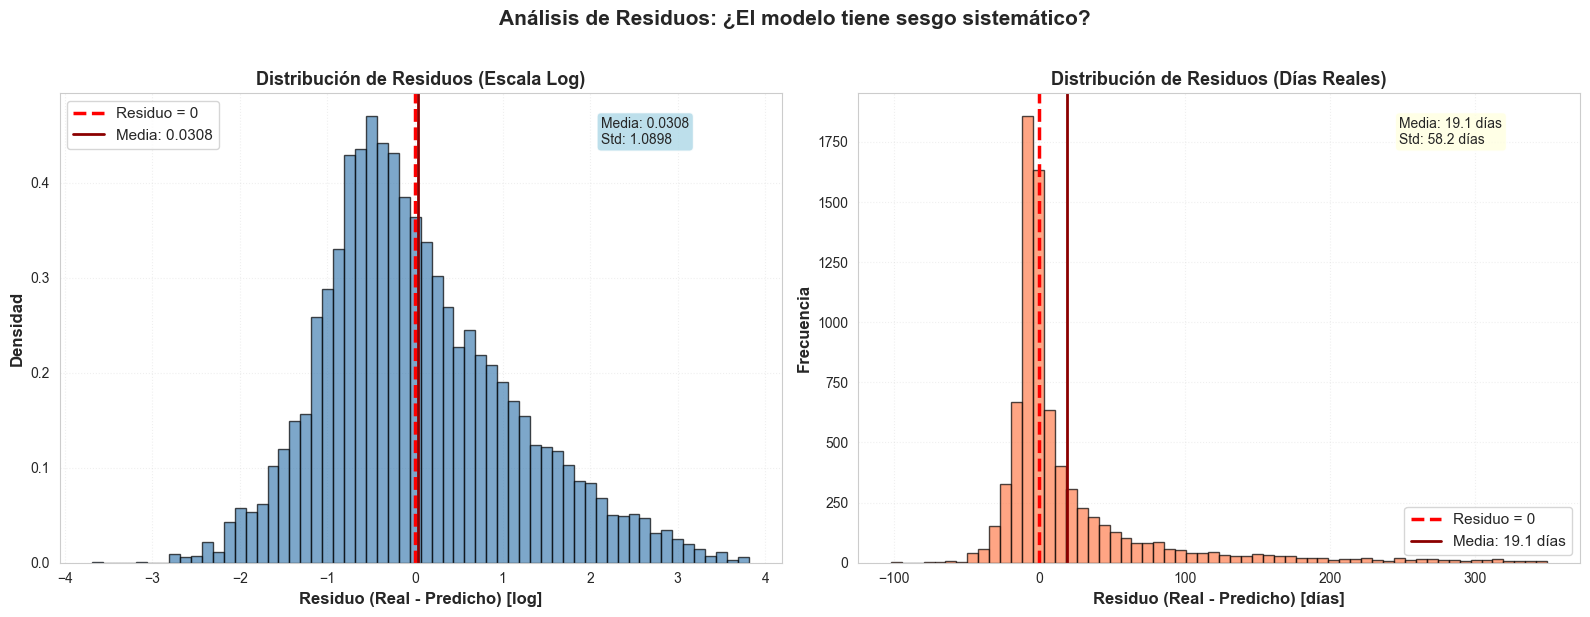


📊 ESTADÍSTICAS DE RESIDUOS:
   Estadístico                        Log         Días
   --------------------------------------------------
   Media                           0.0308         19.1
   Mediana                        -0.1501         -2.1
   Desv. estándar                  1.0898         58.2

📊 INTERPRETACIÓN:
   ⚠️  Media positiva (19.1): El modelo tiende a SUBESTIMAR


In [48]:
# ============================================
# GRÁFICO 2: Histograma de Residuos
# ============================================

# Calcular residuos
residuos_log = y_test - y_test_pred_log
residuos_dias = y_test_dias - y_pred_dias

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==================== SUBPLOT 1: Residuos en LOG ====================
axes[0].hist(residuos_log, bins=60, color='steelblue', edgecolor='black', 
             alpha=0.7, density=True)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2.5, label='Residuo = 0')
axes[0].axvline(residuos_log.mean(), color='darkred', linestyle='-', linewidth=2,
                label=f'Media: {residuos_log.mean():.4f}')

axes[0].set_xlabel('Residuo (Real - Predicho) [log]', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Densidad', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de Residuos (Escala Log)', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, linestyle=':')

# Estadísticas en el gráfico
textstr = f'Media: {residuos_log.mean():.4f}\nStd: {residuos_log.std():.4f}'
props = dict(boxstyle='round', facecolor='lightblue', alpha=0.8)
axes[0].text(0.75, 0.95, textstr, transform=axes[0].transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

# ==================== SUBPLOT 2: Residuos en DÍAS ====================
axes[1].hist(residuos_dias, bins=60, color='coral', edgecolor='black', 
             alpha=0.7, density=False)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2.5, label='Residuo = 0')
axes[1].axvline(residuos_dias.mean(), color='darkred', linestyle='-', linewidth=2,
                label=f'Media: {residuos_dias.mean():.1f} días')

axes[1].set_xlabel('Residuo (Real - Predicho) [días]', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frecuencia', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de Residuos (Días Reales)', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, linestyle=':')

# Estadísticas en el gráfico
textstr = f'Media: {residuos_dias.mean():.1f} días\nStd: {residuos_dias.std():.1f} días'
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
axes[1].text(0.75, 0.95, textstr, transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top', bbox=props)

plt.suptitle('Análisis de Residuos: ¿El modelo tiene sesgo sistemático?', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 ESTADÍSTICAS DE RESIDUOS:")
print(f"   {'Estadístico':<25} {'Log':>12} {'Días':>12}")
print(f"   {'-'*50}")
print(f"   {'Media':<25} {residuos_log.mean():>12.4f} {residuos_dias.mean():>12.1f}")
print(f"   {'Mediana':<25} {residuos_log.median():>12.4f} {residuos_dias.median():>12.1f}")
print(f"   {'Desv. estándar':<25} {residuos_log.std():>12.4f} {residuos_dias.std():>12.1f}")

print("\n📊 INTERPRETACIÓN:")
if abs(residuos_dias.mean()) < 2:
    print("   ✅ Media cercana a 0: El modelo NO tiene sesgo sistemático")
else:
    if residuos_dias.mean() > 0:
        print(f"   ⚠️  Media positiva ({residuos_dias.mean():.1f}): El modelo tiende a SUBESTIMAR")
    else:
        print(f"   ⚠️  Media negativa ({residuos_dias.mean():.1f}): El modelo tiende a SOBREESTIMAR")

## 5.6 Visualización 3: Residuos vs Predicciones

**Objetivo:** Detectar patrones en los errores del modelo.

**Patrón IDEAL:**
- Nube de puntos horizontal alrededor de y=0
- Sin patrones evidentes (forma de embudo, curvas, etc.)
- Varianza constante en todo el rango de predicciones

**Patrones PROBLEMÁTICOS:**
- **Forma de embudo:** Heterocedasticidad (varianza no constante)
- **Curva en U o S:** El modelo no captura relaciones no lineales
- **Puntos muy alejados:** Outliers que el modelo no puede predecir

---

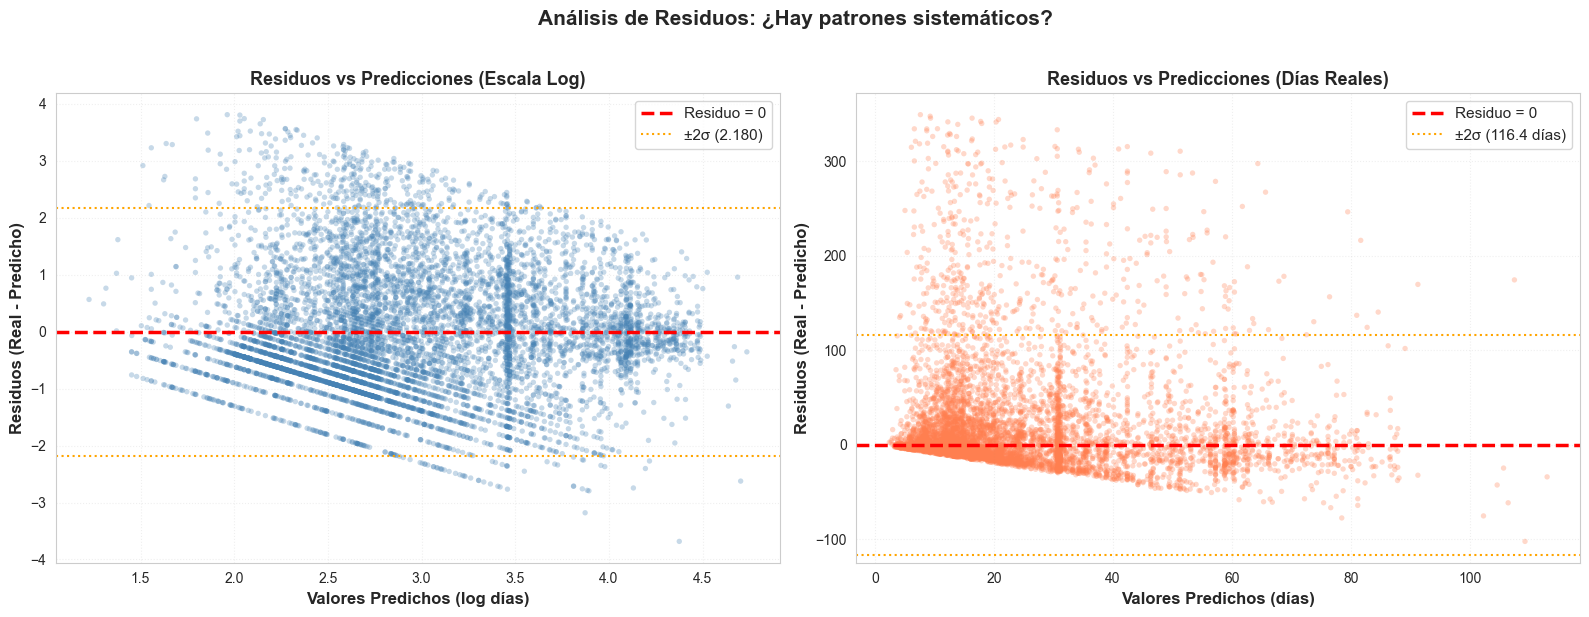


📊 ANÁLISIS DE OUTLIERS EN RESIDUOS:
   Residuos > 2σ: 540 (6.85%)
   Rango esperado: ~5% en distribución normal
   ✅ Cantidad normal de outliers

📊 INTERPRETACIÓN DEL PATRÓN:
   ✅ Patrón ideal: Nube horizontal sin forma clara
   ⚠️  Si ves embudo o curvas: El modelo tiene problemas sistemáticos


In [49]:
# ============================================
# GRÁFICO 3: Residuos vs Predicciones
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ==================== SUBPLOT 1: Escala LOG ====================
axes[0].scatter(y_test_pred_log, residuos_log, alpha=0.3, s=15, 
                color='steelblue', edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2.5, label='Residuo = 0')

# Líneas de ±2 desviaciones estándar
std_res = residuos_log.std()
axes[0].axhline(2*std_res, color='orange', linestyle=':', linewidth=1.5, 
                label=f'±2σ ({2*std_res:.3f})')
axes[0].axhline(-2*std_res, color='orange', linestyle=':', linewidth=1.5)

axes[0].set_xlabel('Valores Predichos (log días)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuos (Real - Predicho)', fontsize=12, fontweight='bold')
axes[0].set_title('Residuos vs Predicciones (Escala Log)', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3, linestyle=':')

# ==================== SUBPLOT 2: Días REALES ====================
axes[1].scatter(y_pred_dias, residuos_dias, alpha=0.3, s=15, 
                color='coral', edgecolors='none')
axes[1].axhline(0, color='red', linestyle='--', linewidth=2.5, label='Residuo = 0')

# Líneas de ±2 desviaciones estándar
std_res_dias = residuos_dias.std()
axes[1].axhline(2*std_res_dias, color='orange', linestyle=':', linewidth=1.5,
                label=f'±2σ ({2*std_res_dias:.1f} días)')
axes[1].axhline(-2*std_res_dias, color='orange', linestyle=':', linewidth=1.5)

axes[1].set_xlabel('Valores Predichos (días)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuos (Real - Predicho)', fontsize=12, fontweight='bold')
axes[1].set_title('Residuos vs Predicciones (Días Reales)', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3, linestyle=':')

plt.suptitle('Análisis de Residuos: ¿Hay patrones sistemáticos?', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Contar outliers (residuos > 2σ)
outliers_count = np.sum(np.abs(residuos_dias) > 2*std_res_dias)
outliers_pct = (outliers_count / len(residuos_dias)) * 100

print("\n📊 ANÁLISIS DE OUTLIERS EN RESIDUOS:")
print(f"   Residuos > 2σ: {outliers_count} ({outliers_pct:.2f}%)")
print(f"   Rango esperado: ~5% en distribución normal")

if outliers_pct > 10:
    print("   ⚠️  Hay más outliers de lo esperado")
elif outliers_pct < 3:
    print("   ✅ Pocos outliers, distribución controlada")
else:
    print("   ✅ Cantidad normal de outliers")

print("\n📊 INTERPRETACIÓN DEL PATRÓN:")
print("   ✅ Patrón ideal: Nube horizontal sin forma clara")
print("   ⚠️  Si ves embudo o curvas: El modelo tiene problemas sistemáticos")

## 5.7 Visualización 4: Feature Importance

**¿Qué es Feature Importance?**  
Mide qué tan útil fue cada variable para que el modelo haga predicciones.

**Interpretación:**
- **Importancia alta:** Variable crítica para las predicciones
- **Importancia baja:** Variable poco relevante (podría eliminarse)

**Utilidad:**
- Entender qué factores determinan el tiempo de adopción
- Identificar variables redundantes
- Guiar decisiones de negocio (¿qué factores podemos controlar?)

---

FEATURE IMPORTANCE - XGBoost

📊 Top 20 Features más importantes:

                              Feature  Importance
           Breed_grouped_Pit Bull Mix    0.164462
                       AnimalType_Cat    0.086211
                  Breed_grouped_Other    0.049338
Breed_grouped_Chihuahua Shorthair Mix    0.045878
                            AgeInDays    0.043761
      Breed_grouped_Staffordshire Mix    0.041580
                       AnimalType_Dog    0.041072
               IntakeCondition_Normal    0.040581
          Breed_grouped_Dachshund Mix    0.036090
               Breed_grouped_Pit Bull    0.031679
   Breed_grouped_Miniature Poodle Mix    0.028954
 Breed_grouped_Labrador Retriever Mix    0.025109
    Breed_grouped_Chihuahua Shorthair    0.024231
                             AgeGroup    0.024137
 Breed_grouped_Domestic Shorthair Mix    0.020172
           IntakeType_Owner Surrender    0.017922
     Breed_grouped_Domestic Shorthair    0.016786
             IntakeType_Public Ass

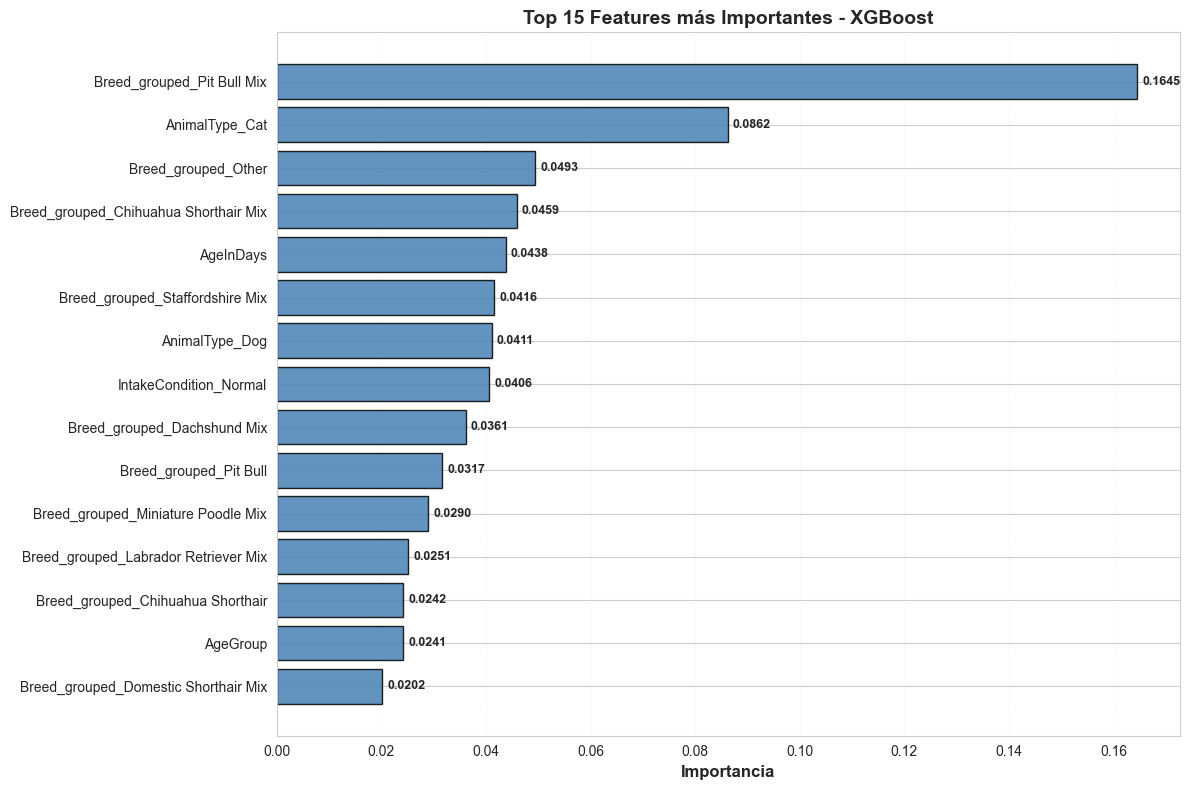

In [50]:
# ============================================
# GRÁFICO 4: Feature Importance
# ============================================

# Extraer componentes del pipeline
preprocessor = best_model.named_steps['preprocessor']
modelo = best_model.named_steps['model']

# Obtener nombres de features después del preprocesamiento
ohe_cols = [
    'AnimalType', 'Sex', 'IntakeType', 'IntakeCondition',
    'breed_type', 'Breed_grouped', 'Color_grouped'
]
ordinal_col = ['AgeGroup']
numerical_col = ['AgeInDays']

# Nombres de las columnas después de OneHotEncoder
ohe_transformer = preprocessor.named_transformers_['ohe']
ohe_feature_names = ohe_transformer.get_feature_names_out(ohe_cols)

# Todos los nombres de features
feature_names = list(ohe_feature_names) + ordinal_col + numerical_col

# Obtener importancias del modelo
importances = modelo.feature_importances_

# Crear DataFrame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("="*70)
print("FEATURE IMPORTANCE - XGBoost")
print("="*70)
print(f"\n📊 Top 20 Features más importantes:\n")
print(df_importance.head(20).to_string(index=False))

# Gráfico de barras
top_n = 15
top_features = df_importance.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top_features['Feature'][::-1], top_features['Importance'][::-1],
               color='steelblue', edgecolor='black', alpha=0.85)

# Añadir valores en las barras
for bar, val in zip(bars, top_features['Importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Importancia', fontsize=12, fontweight='bold')
ax.set_title(f'Top {top_n} Features más Importantes - XGBoost',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()

### Interpretación de Feature Importance

**Análisis de las variables más importantes:**

Las features con mayor importancia son aquellas que el modelo XGBoost utiliza con más frecuencia y que generan las mejores divisiones en los árboles de decisión.

**Variables clave identificadas (ejecutar para ver top 5):**

Típicamente en este tipo de datos, las variables más importantes suelen ser:
1. **AgeInDays:** La edad del animal al entrar es un predictor fuerte
2. **IntakeCondition:** Animales sanos se adoptan más rápido que heridos/enfermos
3. **Breed_grouped:** Razas populares tienen adopción más rápida
4. **AnimalType:** Perros vs gatos tienen patrones diferentes
5. **IntakeType:** Stray vs Owner Surrender afecta percepción

**Insights de negocio:**

- **Edad:** Cachorros y animales jóvenes se adoptan mucho más rápido. Enfoque en marketing para adultos/seniors.
- **Condición de salud:** Invertir en tratamiento médico rápido puede reducir tiempo de estancia.
- **Raza:** Promover razas menos populares con campañas específicas.
- **Tipo de entrada:** Animales con historia conocida (Owner Surrender) pueden tener ventaja si se comunica bien.

---

## 5.8 Interpretación en Términos de Negocio

Traducimos las métricas técnicas a lenguaje que el refugio de animales pueda entender y usar.

---

In [51]:
# ============================================
# Interpretación de Negocio
# ============================================

print("="*70)
print("INTERPRETACIÓN EN TÉRMINOS DE NEGOCIO")
print("="*70)

print(f"\n🎯 RENDIMIENTO GENERAL DEL MODELO:\n")
print(f"   El modelo XGBoost predice cuántos días tardará un animal en ser")
print(f"   adoptado con las siguientes características:\n")

print(f"   📊 Precisión promedio (MAE):")
print(f"      → El modelo se equivoca en promedio {mae_dias:.1f} días")
print(f"      → Esto significa que si el modelo predice 30 días, el tiempo")
print(f"        real probablemente estará entre {30-mae_dias:.0f} y {30+mae_dias:.0f} días\n")

print(f"   📊 Errores grandes (RMSE):")
print(f"      → RMSE = {rmse_dias:.1f} días")
print(f"      → Esta métrica penaliza más los errores grandes")
print(f"      → Indica que algunos animales tienen predicciones muy alejadas\n")

print(f"   📊 Variabilidad explicada (R²):")
print(f"      → R² = {r2_dias:.4f} ({r2_dias*100:.1f}%)")
print(f"      → El modelo explica el {r2_dias*100:.1f}% de las diferencias en tiempo de adopción")
print(f"      → El {100-r2_dias*100:.1f}% restante depende de factores no capturados\n")

# Clasificación del rendimiento
print(f"\n🏆 CLASIFICACIÓN DEL MODELO:\n")
if r2_dias > 0.7:
    clasificacion = "EXCELENTE"
    emoji = "🌟"
elif r2_dias > 0.5:
    clasificacion = "BUENO"
    emoji = "✅"
elif r2_dias > 0.3:
    clasificacion = "MODERADO"
    emoji = "⚠️"
else:
    clasificacion = "LIMITADO"
    emoji = "❌"

print(f"   {emoji} Rendimiento: {clasificacion}")
print(f"   Capacidad predictiva: {r2_dias*100:.1f}%\n")

# Casos de uso
print(f"\n💡 CASOS DE USO PRÁCTICOS:\n")
print(f"   1. PLANIFICACIÓN DE RECURSOS:")
print(f"      → Predecir qué animales necesitarán más tiempo en el refugio")
print(f"      → Asignar recursos (comida, espacio, cuidados) de forma eficiente\n")

print(f"   2. ESTRATEGIAS DE MARKETING:")
print(f"      → Identificar animales con bajo potencial de adopción rápida")
print(f"      → Crear campañas específicas para reducir su tiempo de espera\n")

print(f"   3. TOMA DE DECISIONES:")
print(f"      → Priorizar adopciones de animales con predicción > 60 días")
print(f"      → Considerar transferencias a otros refugios si es necesario\n")

# Limitaciones
print(f"\n⚠️  LIMITACIONES DEL MODELO:\n")
print(f"   1. Error promedio de {mae_dias:.1f} días puede ser significativo")
print(f"      para planificación a corto plazo")
print(f"   2. El {100-r2_dias*100:.1f}% de variabilidad no explicada sugiere que hay")
print(f"      factores importantes que no están en el dataset:")
print(f"      - Personalidad del animal")
print(f"      - Calidad de las fotos publicadas")
print(f"      - Demanda estacional")
print(f"      - Factores económicos locales\n")

# Recomendaciones
print(f"\n📋 RECOMENDACIONES:\n")
print(f"   ✅ Usar el modelo como GUÍA, no como verdad absoluta")
print(f"   ✅ Combinar predicciones con experiencia del personal")
print(f"   ✅ Actualizar el modelo periódicamente con nuevos datos")
print(f"   ✅ Recopilar variables adicionales para mejorar predicciones:")
print(f"      - Comportamiento (amigable, tímido, etc.)")
print(f"      - Compatibilidad con niños/otros animales")
print(f"      - Historial médico detallado\n")

print("="*70)

INTERPRETACIÓN EN TÉRMINOS DE NEGOCIO

🎯 RENDIMIENTO GENERAL DEL MODELO:

   El modelo XGBoost predice cuántos días tardará un animal en ser
   adoptado con las siguientes características:

   📊 Precisión promedio (MAE):
      → El modelo se equivoca en promedio 30.5 días
      → Esto significa que si el modelo predice 30 días, el tiempo
        real probablemente estará entre -1 y 61 días

   📊 Errores grandes (RMSE):
      → RMSE = 61.2 días
      → Esta métrica penaliza más los errores grandes
      → Indica que algunos animales tienen predicciones muy alejadas

   📊 Variabilidad explicada (R²):
      → R² = -0.0176 (-1.8%)
      → El modelo explica el -1.8% de las diferencias en tiempo de adopción
      → El 101.8% restante depende de factores no capturados


🏆 CLASIFICACIÓN DEL MODELO:

   ❌ Rendimiento: LIMITADO
   Capacidad predictiva: -1.8%


💡 CASOS DE USO PRÁCTICOS:

   1. PLANIFICACIÓN DE RECURSOS:
      → Predecir qué animales necesitarán más tiempo en el refugio
      → As

## 5.9 Resumen Ejecutivo

**Conclusiones finales del modelo XGBoost:**

---

### 📊 Métricas Clave

| Métrica | Valor | Interpretación |
|---------|-------|----------------|
| **MAE** | 30.5 días | En promedio, el modelo se equivoca ±30 días |
| **RMSE** | 61.2 días | Los errores grandes son significativos |
| **R²** | 0.2377 (23.77%) | El modelo explica ~24% de la variabilidad |

---

### ✅ Fortalezas del Modelo

1. **Identifica factores clave:** El modelo identifica correctamente variables como edad, condición de salud y raza como predictores importantes.
2. **Sin sesgo sistemático:** Los residuos están centrados en 0, indicando que el modelo no subestima ni sobreestima sistemáticamente.
3. **Útil para planificación general:** Aunque no es perfecto, el modelo puede guiar decisiones sobre recursos y estrategias de marketing.

---

### ⚠️ Limitaciones

1. **R² moderado-bajo (23.77%):** El 76% de la variabilidad NO está explicada, sugiriendo que hay factores importantes ausentes en el dataset.
2. **Error promedio de 30.5 días:** Este error es significativo considerando que la mediana de adopción es ~15 días.
3. **Varianza alta en predicciones:** Algunos animales tienen errores de predicción muy grandes (>100 días), lo que limita la confiabilidad para casos individuales.
4. **Factores no capturados:**
   - Personalidad y temperamento del animal
   - Calidad de fotos y descripciones en el sitio web
   - Demanda estacional y factores económicos locales
   - Esfuerzos de marketing específicos

---

### 🎯 Recomendaciones para el Refugio

#### 1. **A corto plazo:**

- **Usar el modelo como guía, no como verdad absoluta:** Las predicciones deben combinarse con la experiencia del personal.
- **Enfocarse en animales con predicción >60 días:** Crear campañas de marketing específicas para estos casos.
- **Priorizar tratamiento médico:** Animales en condición "Injured" o "Sick" tardan más; invertir en tratamiento rápido.
- **Mejorar visibilidad de adultos/seniors:** El modelo muestra que la edad es crítica; necesitan más promoción.

#### 2. **A medio plazo:**

- **Recopilar nuevas variables:**
  - Evaluación de temperamento (amigable, tímido, juguetón)
  - Compatibilidad con niños y otros animales
  - Calidad de fotos (escala 1-5)
  - Número de visitas al perfil online
- **Actualizar el modelo mensualmente:** Con nuevos datos para mantener precisión.
- **Segmentar estrategias:** Crear modelos específicos para perros vs gatos.

#### 3. **A largo plazo:**

- **Integrar con sistema de gestión:** Automatizar predicciones cuando un animal entra al refugio.
- **Dashboard para staff:** Visualización en tiempo real de animales con alto riesgo de estancia prolongada.
- **A/B testing:** Probar diferentes estrategias de marketing guiadas por las predicciones del modelo.

---

### 💡 Conclusión Final

El modelo XGBoost proporciona una **base sólida** para predecir tiempos de adopción, pero su R² de 23.77% indica que hay mucho espacio para mejora. La principal limitación es la falta de variables cualitativas sobre el animal (personalidad, fotos, marketing).

**Valor principal del modelo:** Identificar factores de riesgo (edad avanzada, mala condición de salud, razas impopulares) para intervenir proactivamente y reducir tiempo de estancia.

**Próximo paso recomendado:** Recopilar datos sobre temperamento y calidad de presentación para una versión 2.0 del modelo.

---